After working with Andy's code to generate plots in exploringAndy.ipynb, I noticed a weird thing where there were numerous detections at the maximum energy that are clear outliers. For clarity, I continue looking at the data where I left off in exploringAndy.ipynb, so that this is really more exploring how to fit and plot the data and exploringAndy.ipynb is looking at Andy's code to get a sense of things

In [1]:
from andylib import load_file
import os
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def extract_from_parent(n_channels,parent_dir):

   raw_dir = os.path.join(parent_dir, "RAW")

   # if not os.path.isdir(raw_dir):
   #    raise FileNotFoundError(f"RAW subdirectory not found: {raw_dir}")

   channel_data = [[],[],[],[],[]]
   channel_indices = [0]
   for i in range(n_channels):
      # if not os.path.isdir(parent_dir):
      #    raise ValueError(f"Parent directory does not exist: {parent_dir}")

      raw_dir = os.path.join(parent_dir, "RAW")

      channel_token = f"CH{i}"
      candidates = [fname for fname in os.listdir(raw_dir)
                    if os.path.isfile(os.path.join(raw_dir, fname)) and channel_token in fname]
      channel_filename = candidates[0]
      file_path = os.path.join(raw_dir, channel_filename)
      ret = load_file(file_path, lowmem=True)
      channel_indices.append(len(ret[0])+channel_indices[i])
      for i in range(len(channel_data)):
         for j in range(len(ret[i])):
            channel_data[i].append(ret[i][j])
   return np.array(channel_data),channel_indices[1:-1]

[11900, 22100]
(5, 33280)


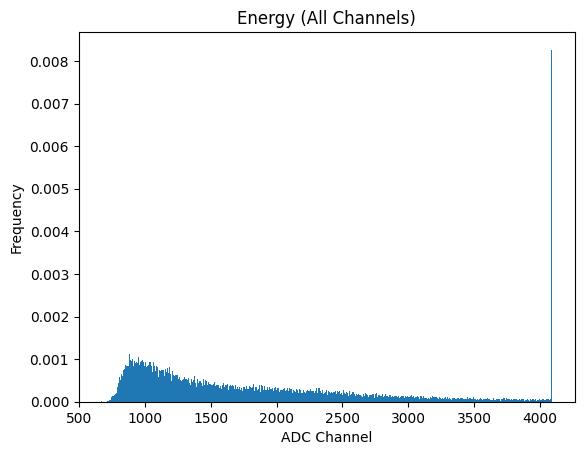

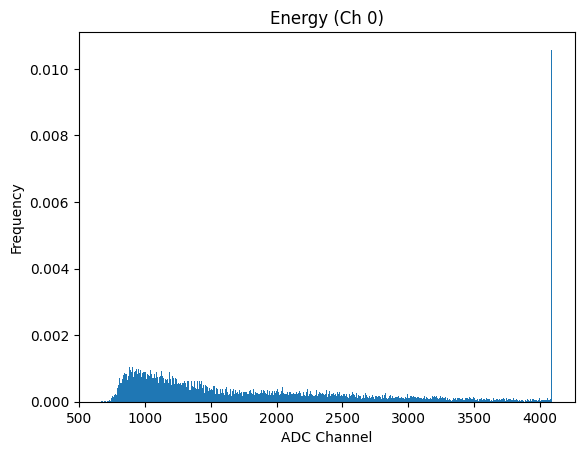

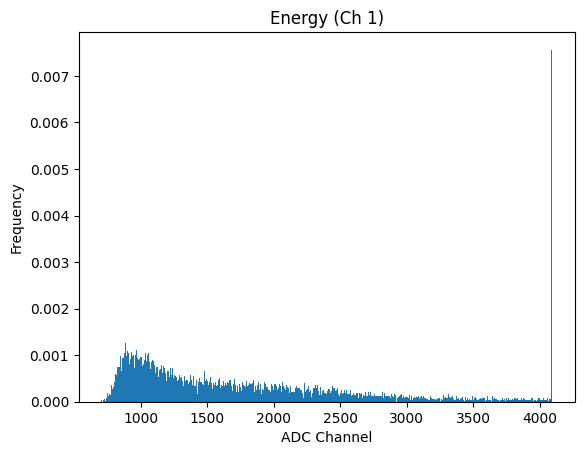

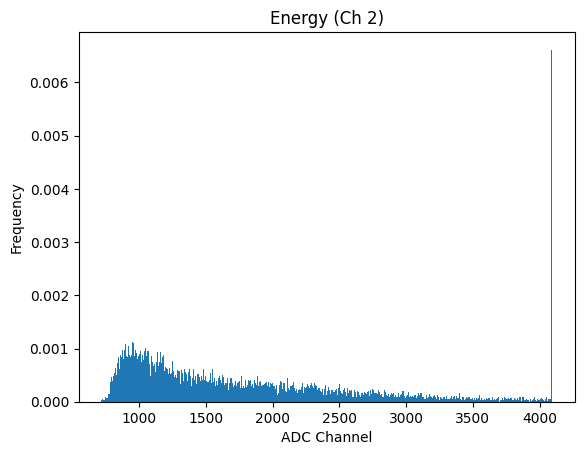

In [3]:
n_channels, parent_dir = 3,"Scenario_5_Revised_Run"
data,indices = extract_from_parent(n_channels,parent_dir)
print(indices)
print(data.shape)
aggregate_energy = data[2]

plt.title("Energy (All Channels)")
plt.xlabel("ADC Channel")
plt.ylabel("Frequency")
plt.hist(aggregate_energy,bins=500,density=True)
plt.show()

plt.title("Energy (Ch 0)")
plt.xlabel("ADC Channel")
plt.ylabel("Frequency")
plt.hist(aggregate_energy[:indices[0]],bins=500,density=True)
plt.show()

plt.title("Energy (Ch 1)")
plt.xlabel("ADC Channel")
plt.ylabel("Frequency")
plt.hist(aggregate_energy[indices[0]:indices[1]],bins=500,density=True)
plt.show()

plt.title("Energy (Ch 2)")
plt.xlabel("ADC Channel")
plt.ylabel("Frequency")
plt.hist(aggregate_energy[indices[1]:],bins=500,density=True)
plt.show()

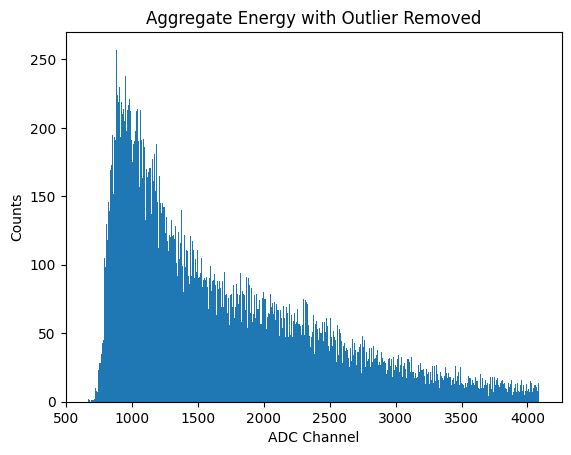

In [6]:
# Remove the weird spike
n,bins = np.histogram(aggregate_energy,bins=500)
n,bins = n[:-1],bins[:-1]
half_bins = np.array([(bins[i]+bins[i+1])/2 for i in range(len(bins)-1)])

bin_width = bins[1]-bins[0]

plt.title("Aggregate Energy with Outlier Removed")
plt.xlabel("ADC Channel")
plt.ylabel("Counts")
plt.bar(half_bins,n,width=bin_width)
plt.show()



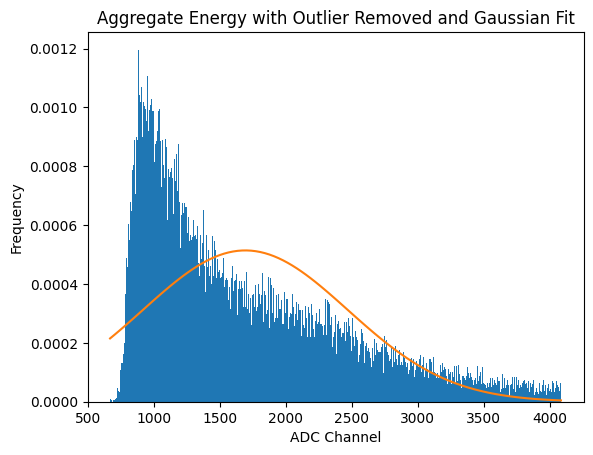

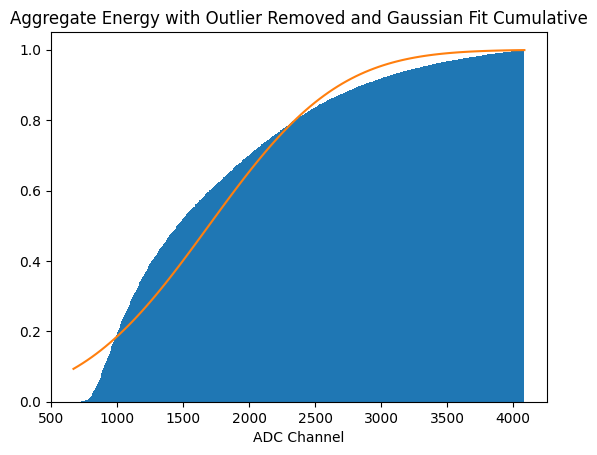

In [7]:
from scipy.stats import norm

back2data = []
for i in range(len(n)):
   for j in range(int(n[i])):
      back2data.append(half_bins[i])

mean,std=norm.fit(back2data)
# print(mean,std)
xmin,xmax = min(half_bins),max(half_bins)
# print(xmin,xmax)
x = np.linspace(xmin, xmax, 100)
y_pdf = norm.pdf(x, mean, std)
# print(y_pdf)

plt.title("Aggregate Energy with Outlier Removed and Gaussian Fit")
plt.xlabel("ADC Channel")
plt.ylabel("Frequency")
plt.hist(back2data,bins=499,density=True)
plt.plot(x,y_pdf)
plt.show()

y_cdf = norm.cdf(x, mean, std)
plt.title("Aggregate Energy with Outlier Removed and Gaussian Fit Cumulative")
plt.xlabel("ADC Channel")
plt.hist(back2data,bins=499,density=True,cumulative=True)
plt.plot(x,y_cdf)
plt.show()

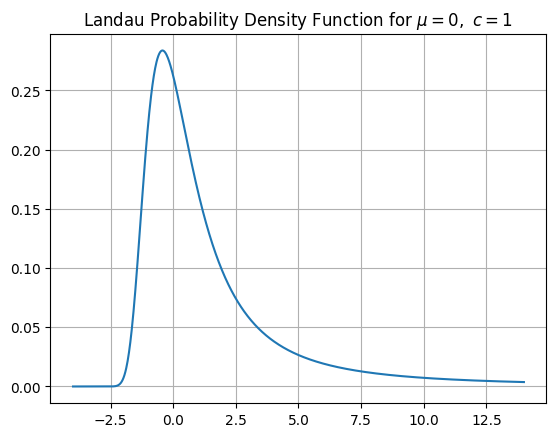

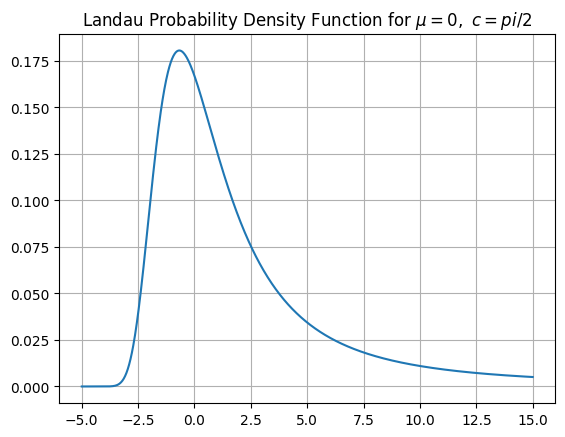

In [8]:
from scipy.stats import landau
from scipy.constants import pi

x = np.linspace(-4,14,1000)
plt.title(r"Landau Probability Density Function for $\mu=0,~c=1$")
plt.plot(x,landau.pdf(x,0,1))
plt.grid(True)
plt.show()

x = np.linspace(-5,15,1000)
plt.title(r"Landau Probability Density Function for $\mu=0,~c=pi/2$")
plt.plot(x,landau.pdf(x,0,pi/2))
plt.grid(True)
plt.show()

[1209.27704889  349.23541492] [10.47500725  8.02121459]


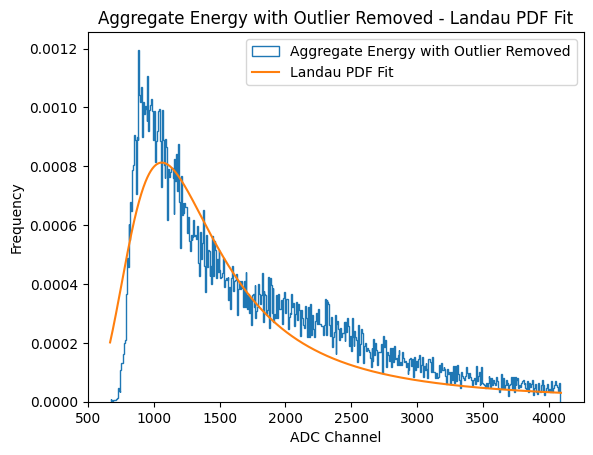

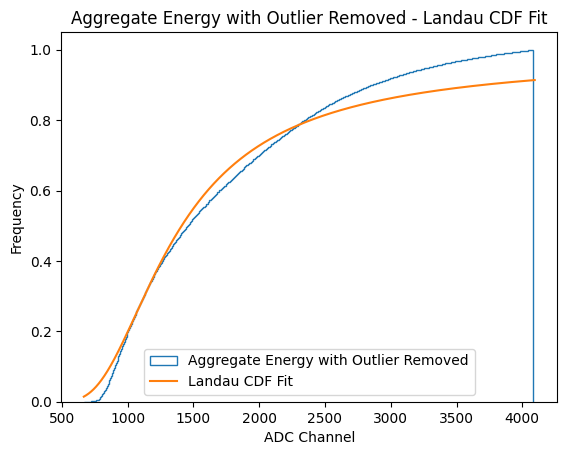

In [9]:
from scipy.optimize import curve_fit

n,bins = np.histogram(aggregate_energy,bins=len(aggregate_energy),density=True)
n,bins = n[:-1],bins[:-1]
half_bins = np.array([(bins[i]+bins[i+1])/2 for i in range(len(bins)-1)])

popt, pcov = curve_fit(lambda x, mu, c: landau.pdf(x, loc=mu, scale=c), half_bins, n)
perr = np.sqrt(np.diag(pcov))

print(popt,perr)

landau_pdf,landau_cdf = landau.pdf(half_bins,loc=popt[0],scale=popt[1]),landau.cdf(half_bins,loc=popt[0],scale=popt[1])

plt.title("Aggregate Energy with Outlier Removed - Landau PDF Fit")
plt.xlabel("ADC Channel")
plt.ylabel("Frequency")
plt.hist(back2data,bins=499,label="Aggregate Energy with Outlier Removed",histtype="step",density=True)
plt.plot(half_bins,landau_pdf,label="Landau PDF Fit")
plt.legend()
plt.show()

plt.title("Aggregate Energy with Outlier Removed - Landau CDF Fit")
plt.xlabel("ADC Channel")
plt.ylabel("Frequency")
plt.hist(back2data,bins=499,label="Aggregate Energy with Outlier Removed",histtype="step",density=True,cumulative=True)
plt.plot(half_bins,landau_cdf,label="Landau CDF Fit")
plt.legend()
plt.show()

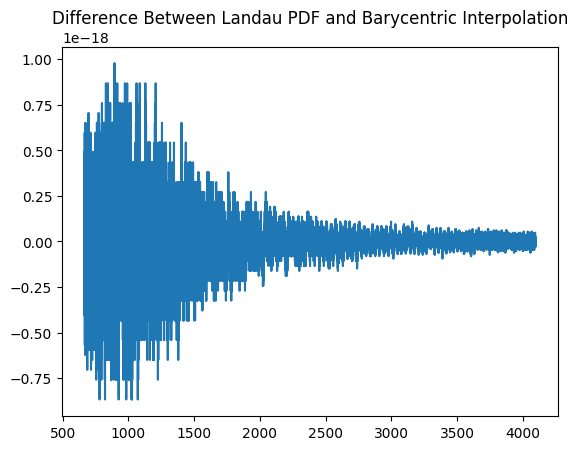

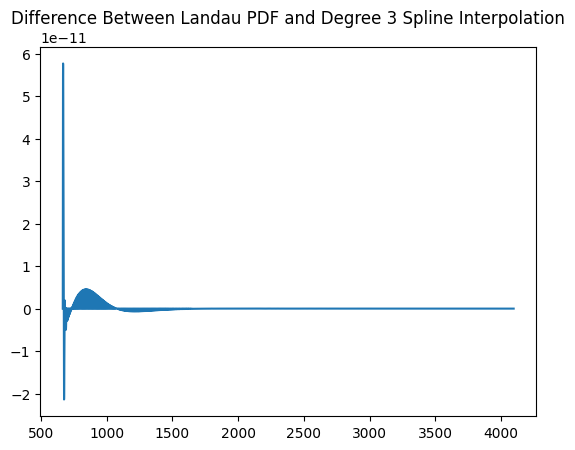

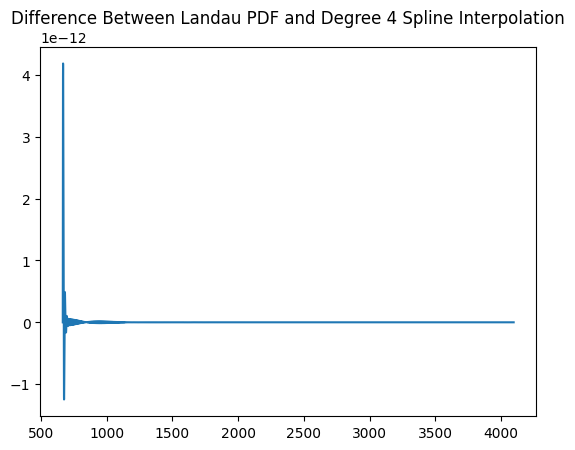

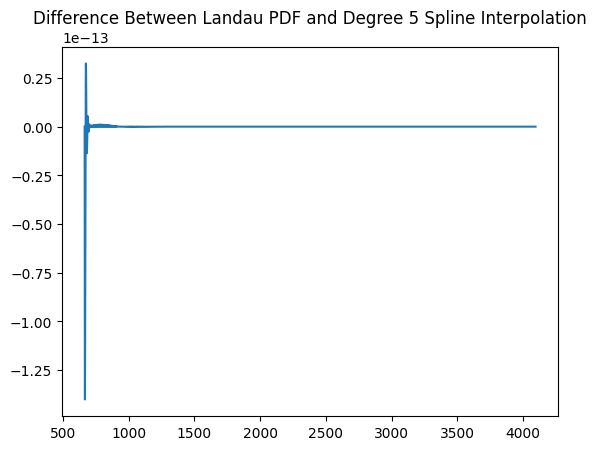

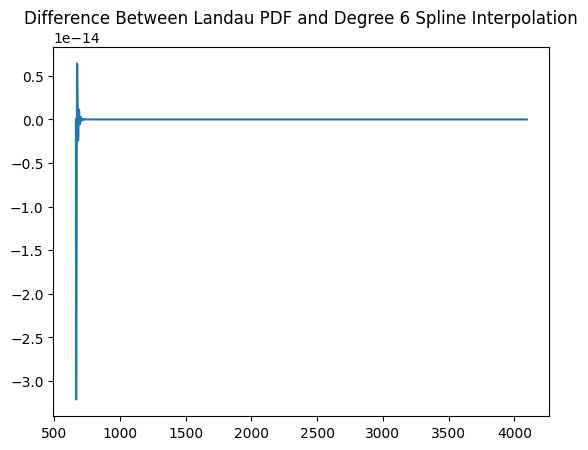

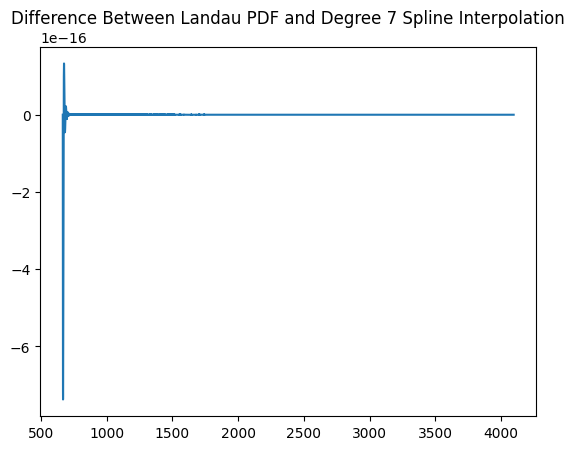

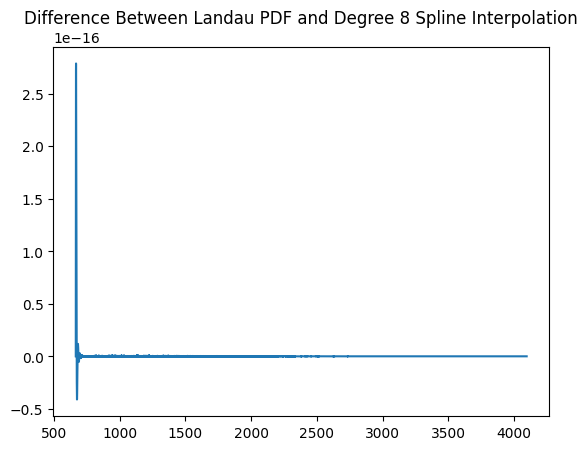

In [10]:
from scipy.interpolate import BarycentricInterpolator,make_interp_spline
from numpy.polynomial.chebyshev import chebpts1

tabx = (chebpts1(300)+1)*(half_bins[-1]-half_bins[0])/2+half_bins[0]
taby = landau.pdf(tabx,loc=popt[0],scale=popt[1])
baryinterp_landau_pdf = BarycentricInterpolator(tabx,taby)

plt.title("Difference Between Landau PDF and Barycentric Interpolation")
plt.plot(half_bins,landau_pdf-baryinterp_landau_pdf(half_bins))
plt.show()

for i in range(3,9):
   tabx = np.linspace(half_bins[0],half_bins[-1],497)
   taby = landau.pdf(tabx,loc=popt[0],scale=popt[1])
   splineinterp_landau_pdf = make_interp_spline(tabx,taby,i)

   plt.title(f"Difference Between Landau PDF and Degree {i} Spline Interpolation")
   plt.plot(half_bins,landau_pdf-splineinterp_landau_pdf(half_bins))
   plt.show()

Based on these plots, I decided to go with the barycentric interpolation

/var/folders/mp/wxx05wqx5tz5qykh9r4x9c4c0000gn/T/ipykernel_33061/1368029503.py:22: RuntimeWarning: invalid value encountered in divide
  conv_values /= norm_factor


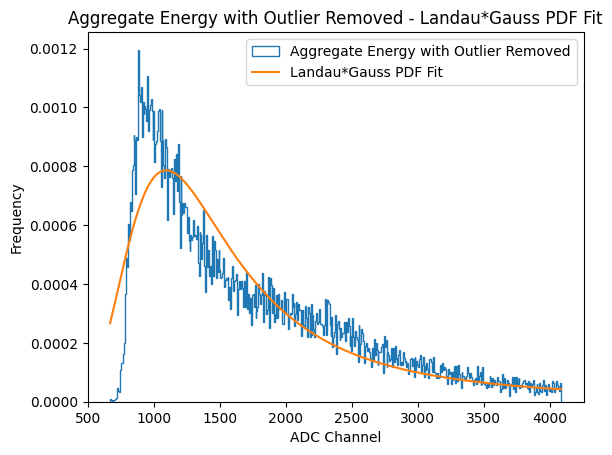

Fitted parameters: [7.90302025e-10 4.13629327e+02 1.23306528e+03 4.04891526e+00]


In [11]:
# Note: This cell takes a couple minutes to run

from scipy.integrate import quad
from scipy.optimize import curve_fit
# from scipy.interpolate import interp1d
import numpy as np

# Improved convolution: pre-compute on a grid and interpolate for speed
def landau_star_gauss_interp(x, mu, c, x0, sigma, grid_size=300):
    # Define a fine grid over the data range
    # x_grid = np.linspace(np.min(half_bins), np.max(half_bins), grid_size) # For speed w/ interp1d
    x_grid = (chebpts1(grid_size)+1)*(half_bins[-1]-half_bins[0])/2+half_bins[0] # For use w/ BarycentricInterpolator
    conv_values = []
    for xi in x_grid:
        # Narrow limits to data range for stability
        result = quad(lambda t: landau.pdf((xi - t), loc=mu, scale=c) * norm.pdf(t, x0, sigma),
                      np.min(half_bins), np.max(half_bins), limit=100)[0]
        conv_values.append(result)
    conv_values = np.array(conv_values)
    # Normalize 
    norm_factor = np.trapezoid(conv_values, x_grid) # For speed
    conv_values /= norm_factor
    # Interpolate
    # interp_func = interp1d(x_grid, conv_values, kind='linear', bounds_error=False, fill_value=0) # For speed
    interp_func = BarycentricInterpolator(x_grid,conv_values) # Better Interpolation
    return interp_func(x)

n, bins = np.histogram(aggregate_energy, bins=500, density=True)
n, bins = n[:-1], bins[:-1]
half_bins = np.array([(bins[i] + bins[i+1]) / 2 for i in range(len(bins) - 1)])

# Initial guesses: based on prior Landau fit and data estimates
p0 = [1209, 349, np.mean(half_bins), np.std(half_bins)]  # mu, c, x0, sigma

# Fit with bounds to prevent negative sigma
bounds = ([0, 0, np.min(half_bins), 0], [np.inf, np.inf, np.max(half_bins), np.inf])
popt, pcov = curve_fit(lambda x, mu, c, x0, sigma: landau_star_gauss_interp(x, mu, c, x0, sigma),
                       half_bins, n, p0=p0, bounds=bounds)

# Compute fitted values
landau_star_gauss_pdf = landau_star_gauss_interp(half_bins, *popt)

# Plot
plt.title("Aggregate Energy with Outlier Removed - Landau*Gauss PDF Fit")
plt.xlabel("ADC Channel")
plt.ylabel("Frequency")
plt.hist(back2data, bins=499, label="Aggregate Energy with Outlier Removed", histtype="step", density=True)
plt.plot(half_bins, landau_star_gauss_pdf, label="Landau*Gauss PDF Fit")
plt.legend()
plt.show()

print("Fitted parameters:", popt)

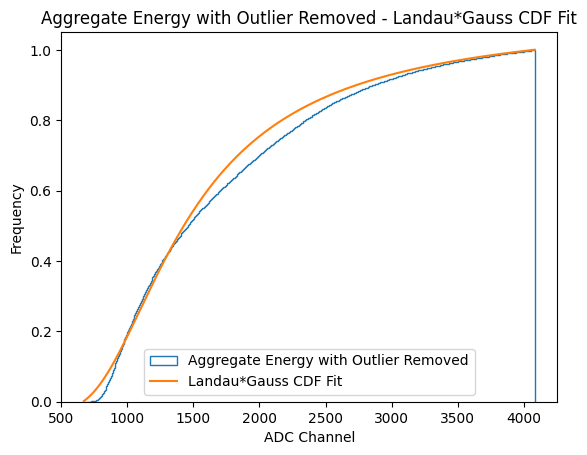

In [12]:
y_cdf = np.cumsum(landau_star_gauss_pdf) * (half_bins[1] - half_bins[0])

plt.title("Aggregate Energy with Outlier Removed - Landau*Gauss CDF Fit")
plt.xlabel("ADC Channel")
plt.ylabel("Frequency")
plt.hist(back2data, bins=499, label="Aggregate Energy with Outlier Removed", histtype="step", density=True, cumulative=True)
plt.plot(half_bins, y_cdf, label="Landau*Gauss CDF Fit")
plt.legend()
plt.show()

In [13]:
from scipy.stats import exponnorm
from scipy.optimize import root_scalar

def pdf2cdf(x,y_pdf):
   '''
   Given a set of x,y_pdf values which make up a pdf, 
   returns the y_cdf values which correspond to the cdf of that distribution with the same x values
   '''
   dx = np.diff(x)
   y_cdf = np.empty_like(y_pdf)
   y_cdf[0] = 0
   y_cdf[1:] = np.cumsum((y_pdf[:-1] + y_pdf[1:]) / 2 * dx)
   return y_cdf / y_cdf[-1]

def get_thresh(x,y_cdf,rate=1e-3):
   interp = make_interp_spline(x,y_cdf,5)
   return root_scalar(lambda t:interp(t)-rate,bracket=(min(x),max(x))).root

def exp_mod_gauss_fit(data):
   '''
   Given a set of data, fits an exponentially modified Gaussian distribution
   Returns:
   K,sigma_K,mean,sigma_mean,std,sigma_std - The fit parameters mu,c as well as an estimate of their error
   '''
   n,bins = np.histogram(data,bins=len(data),density=True)
   n,bins = n[:-1],bins[:-1]
   half_bins = np.array([(bins[i]+bins[i+1])/2 for i in range(len(bins)-1)])
   p0 = np.array([1,np.mean(data),np.std(data)])
   popt, pcov = curve_fit(lambda x, K, mean, std: exponnorm.pdf(x, K, mean,std), half_bins, n,p0=p0)
   K,mean,std = popt
   sigma_K,sigma_mean,sigma_std=np.sqrt(np.diag(pcov))
   return K,sigma_K,mean,sigma_mean,std,sigma_std

def plot_hist_with_fit(data,xfit,yfit,data_type="",xlabel="",fit_type=""):
   plt.title(f"{data_type} Histogram with {fit_type} PDF Fit")
   plt.xlabel(xlabel)
   plt.ylabel("Frequency")
   plt.hist(data,bins=249,density=True,histtype='step')
   plt.plot(xfit,yfit,label=f'{fit_type} '+'PDF Fit')
   plt.legend()
   plt.show()

   y_cdf = pdf2cdf(xfit,yfit)
   thresh = get_thresh(xfit,y_cdf)
   plt.title(f"{data_type} Histogram with {fit_type} CDF Fit")
   plt.xlabel(xlabel)
   plt.ylabel("Frequency")
   plt.hist(data,bins=249,density=True,cumulative=True,histtype='step')
   plt.plot(xfit,y_cdf,label=f'{fit_type} '+'CDF Fit')
   plt.plot(thresh,make_interp_spline(xfit,y_cdf,5)(thresh),label="0.1% Threshold",marker="x",linestyle="")
   plt.yscale('log')
   plt.legend()
   plt.show()

22.94983721026299 804.8678448027139 41.16982579170238


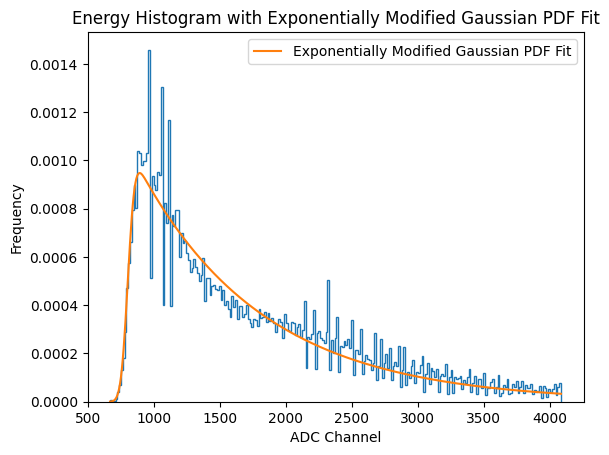

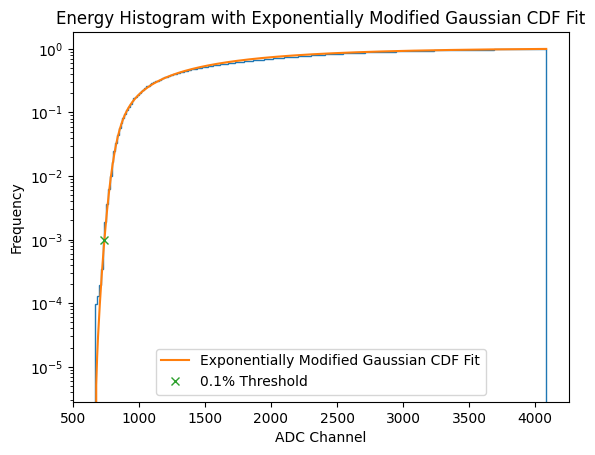

In [14]:



data = back2data
K,sigma_K,mean,sigma_mean,std,sigma_std = exp_mod_gauss_fit(data)
print(K,mean,std)
xfit = half_bins
yfit = exponnorm.pdf(xfit,K,mean,std)
plot_hist_with_fit(data,xfit,yfit,"Energy","ADC Channel","Exponentially Modified Gaussian")

In [15]:
n,bins = np.histogram(aggregate_energy,bins=len(aggregate_energy))
print(n[-1],bins[-2:])

E4095 = np.sum(aggregate_energy==4095)
print(E4095)

mask = aggregate_energy!=4095
new_aggregate_energy = aggregate_energy[mask]

E4095 = np.sum(new_aggregate_energy==4095)
print(E4095)

def remove_overflow(data):
   max_val = max(data)
   if np.log2(max_val+1).is_integer(): # Highly suspicious, likely overflow
      mask = data!=max_val
      return data[mask],len(data)-len(data[mask])
   else: # No overflow
      return data,0

n,bins = np.histogram(aggregate_energy,bins=len(aggregate_energy))
print(n[-1],bins[-2:])

E4095 = np.sum(aggregate_energy==4095)
print(E4095)

new_aggregate_energy = remove_overflow(aggregate_energy)

E4095 = np.sum(new_aggregate_energy==4095)
print(E4095)

1882 [4094.89696514 4095.        ]
1882
0
1882 [4094.89696514 4095.        ]
1882
0


In [16]:
from scipy.stats import chisquare

n,bins = np.histogram(remove_overflow(aggregate_energy)[0],bins=len(aggregate_energy)-remove_overflow(aggregate_energy)[1])
n,bins = np.histogram(remove_overflow(aggregate_energy)[0],bins="fd")
print(len(bins))
half_bins = np.array([(bins[i]+bins[i+1])/2 for i in range(len(bins)-1)])
K,sigma_K,mean,sigma_mean,std,sigma_std = exp_mod_gauss_fit(remove_overflow(aggregate_energy)[0])


fit_fxn = lambda x: exponnorm.cdf(x, K, loc=mean, scale=std)

def chi2(bins,n,fit_cdf,n_params):
   expected_probs = fit_cdf(bins[1:]) - fit_cdf(bins[:-1])
   expected_probs /= np.sum(expected_probs) # Normalize
   expected = np.sum(n) * expected_probs
   # print(np.sum(n),np.sum(expected),np.sum(expected_probs))
   print(np.min(expected))
   return chisquare(n,f_exp=expected,ddof=n_params)

print(r"$\chi^2$: "+f"{chi2(bins,n,fit_fxn,3).statistic}\np-value: {chi2(bins,n,fit_fxn,3).pvalue}")

def R2(half_bins,n,fit_fxn):
   residuals = n - fit_fxn(half_bins)
   ss_res = np.sum(residuals**2)
   ss_tot = np.sum((n-np.mean(n))**2)
   r_squared = 1 - (ss_res / ss_tot)
   return r_squared


print(f"$R^2$: {R2(half_bins,n,fit_fxn)}")

n,bins = np.histogram(remove_overflow(aggregate_energy)[0],bins="fd")
print(len(bins))
half_bins = np.array([(bins[i]+bins[i+1])/2 for i in range(len(bins)-1)])
K,sigma_K,mean,sigma_mean,std,sigma_std = exp_mod_gauss_fit(remove_overflow(aggregate_energy)[0])
print(r"$\chi^2$: "+f"{chi2(bins,n,fit_fxn,3).statistic}\np-value: {chi2(bins,n,fit_fxn,3).pvalue}")
print(f"$R^2$: {R2(half_bins,n,fit_fxn)}")

50
25.989286953463573
25.989286953463573
$\chi^2$: 458.3505992601362
p-value: 7.577409332478486e-70
$R^2$: -1.3138991560392737
50
25.989286953463573
25.989286953463573
$\chi^2$: 458.3505992601362
p-value: 7.577409332478486e-70
$R^2$: -1.3138991560392737


This seems to suggest that the $p$-value determined by $\chi^2$ is not helpful
Alternatives to look into:
 - Kolmogorov–Smirnov test (scipy.stats.kstest)
 - Anderson–Darling (similar to kstest with more weight to the tails?)
 - ???

In [17]:
from scipy.stats import kstest

ret = kstest(remove_overflow(aggregate_energy)[0],fit_fxn)
print(f"Statistic: {ret.statistic}\np-value: {ret.pvalue}")

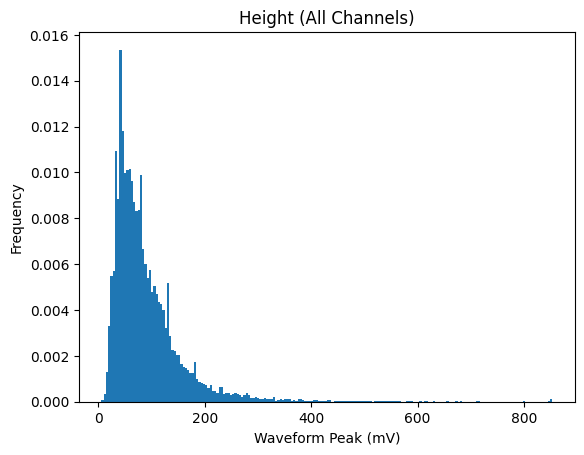

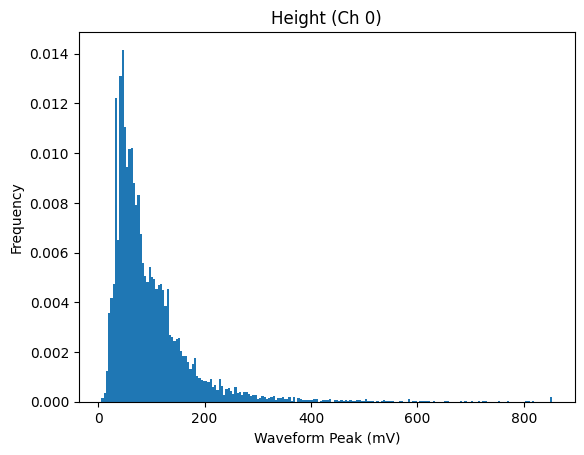

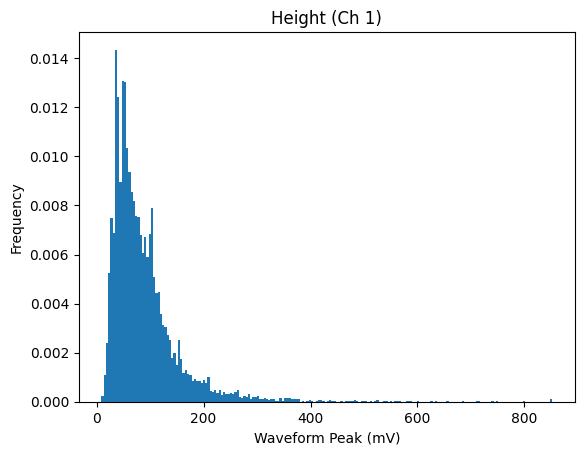

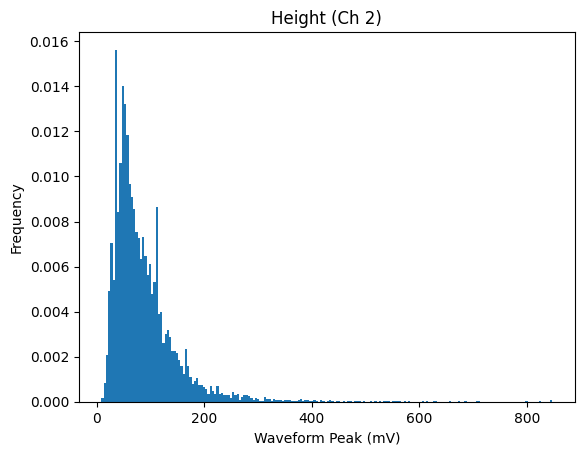

In [18]:
n_channels, parent_dir = 3,"Scenario_5_Revised_Run"
data,indices = extract_from_parent(n_channels,parent_dir)
aggregate_height = data[0]

plt.title("Height (All Channels)")
plt.xlabel("Waveform Peak (mV)")
plt.ylabel("Frequency")
plt.hist(aggregate_height,bins=200,density=True)
plt.show()

plt.title("Height (Ch 0)")
plt.xlabel("Waveform Peak (mV)")
plt.ylabel("Frequency")
plt.hist(aggregate_height[:indices[0]],bins=200,density=True)
plt.show()

plt.title("Height (Ch 1)")
plt.xlabel("Waveform Peak (mV)")
plt.ylabel("Frequency")
plt.hist(aggregate_height[indices[0]:indices[1]],bins=200,density=True)
plt.show()

plt.title("Height (Ch 2)")
plt.xlabel("Waveform Peak (mV)")
plt.ylabel("Frequency")
plt.hist(aggregate_height[indices[1]:],bins=200,density=True)
plt.show()

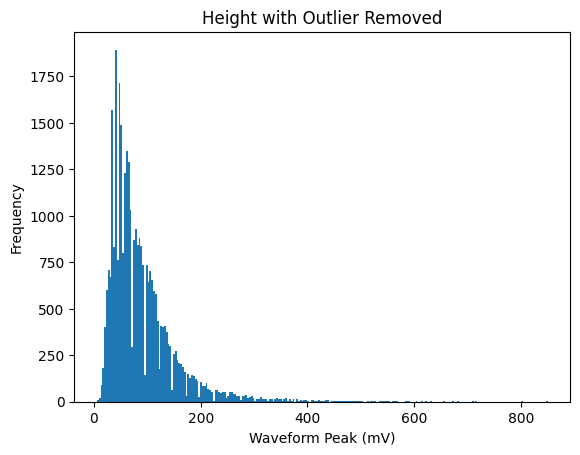

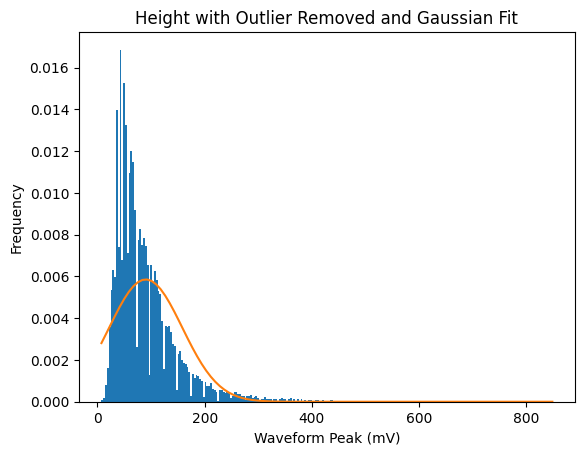

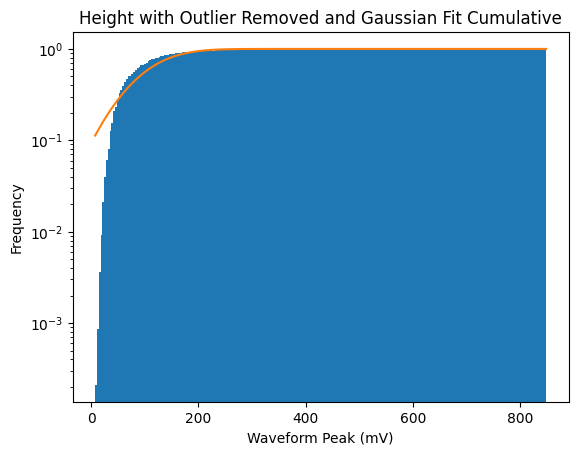

In [19]:
# Remove the weird spike
n,bins = np.histogram(aggregate_height,bins=250)
n,bins = n[:-1],bins[:-1]
half_bins = np.array([(bins[i]+bins[i+1])/2 for i in range(len(bins)-1)])

bin_width = half_bins[1]-half_bins[0]

plt.title("Height with Outlier Removed")
plt.xlabel("Waveform Peak (mV)")
plt.ylabel("Frequency")
plt.bar(half_bins,n,width=bin_width)
plt.show()

back2data = []
for i in range(len(n)):
   for j in range(int(n[i])):
      back2data.append(half_bins[i])

mean,std=norm.fit(back2data)
xmin,xmax = min(half_bins),max(half_bins)
x = np.linspace(xmin, xmax, 100)
y_pdf = norm.pdf(x, mean, std)

plt.title("Height with Outlier Removed and Gaussian Fit")
plt.xlabel("Waveform Peak (mV)")
plt.ylabel("Frequency")
plt.hist(back2data,bins=249,density=True)
plt.plot(x,y_pdf)
plt.show()

y_cdf = norm.cdf(x, mean, std)
plt.title("Height with Outlier Removed and Gaussian Fit Cumulative")
plt.xlabel("Waveform Peak (mV)")
plt.ylabel("Frequency")
plt.hist(back2data,bins=249,density=True,cumulative=True)
plt.plot(x,y_cdf)
plt.yscale('log')
plt.show()

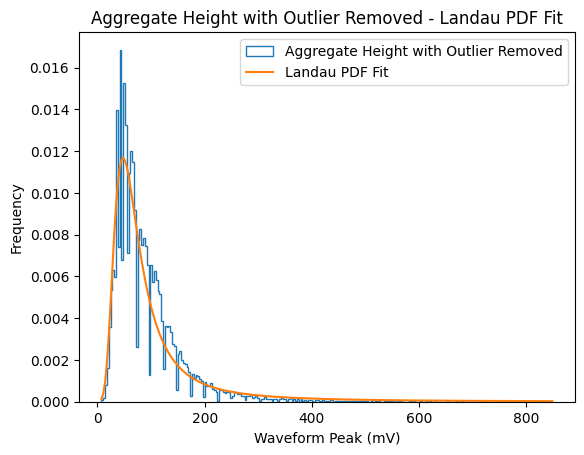

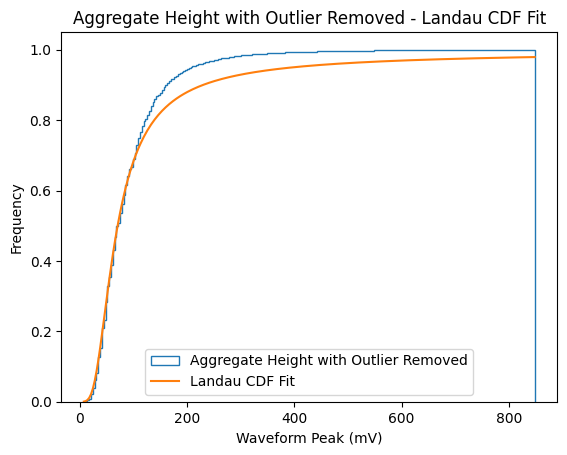

[58.29360154 24.28152273]


In [20]:
n,bins = np.histogram(aggregate_height,bins=250,density=True)
n,bins = n[:-1],bins[:-1]
half_bins = np.array([(bins[i]+bins[i+1])/2 for i in range(len(bins)-1)])

popt, pcov = curve_fit(lambda x, mu, c: landau.pdf(x, loc=mu, scale=c), half_bins, n)

landau_pdf = landau.pdf(half_bins,loc=popt[0],scale=popt[1])

plt.title("Aggregate Height with Outlier Removed - Landau PDF Fit")
plt.xlabel("Waveform Peak (mV)")
plt.ylabel("Frequency")
plt.hist(back2data,bins=249,label="Aggregate Height with Outlier Removed",histtype="step",density=True)
plt.plot(half_bins,landau_pdf,label="Landau PDF Fit")
plt.legend()
plt.show()

plt.title("Aggregate Height with Outlier Removed - Landau CDF Fit")
plt.xlabel("Waveform Peak (mV)")
plt.ylabel("Frequency")
plt.hist(back2data,bins=249,label="Aggregate Height with Outlier Removed",histtype="step",density=True,cumulative=True)
plt.plot(half_bins,np.cumsum(landau_pdf)*(half_bins[1] - half_bins[0]),label="Landau CDF Fit")
plt.legend()
plt.show()

print(popt)

/var/folders/mp/wxx05wqx5tz5qykh9r4x9c4c0000gn/T/ipykernel_33061/1368029503.py:22: RuntimeWarning: invalid value encountered in divide
  conv_values /= norm_factor


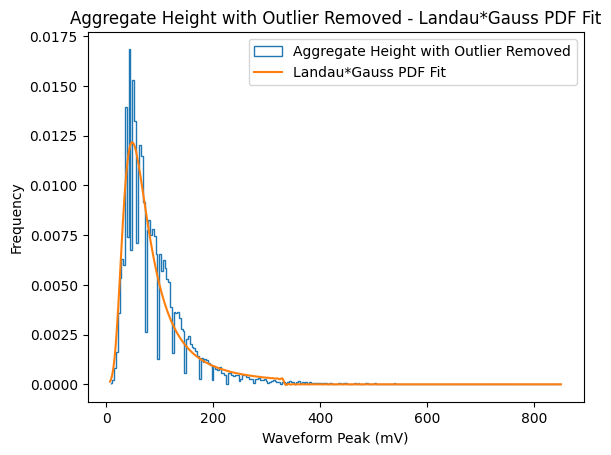

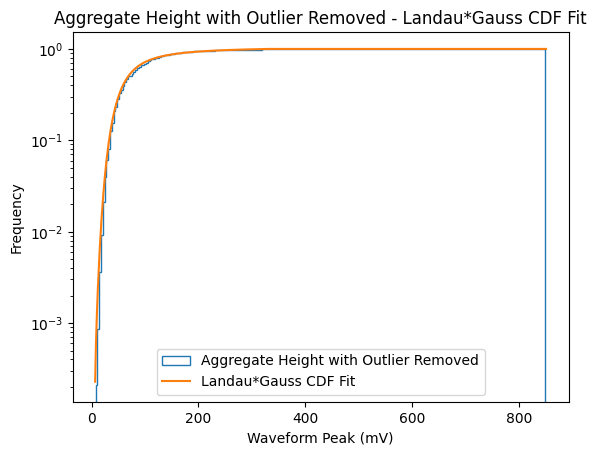

Fitted parameters: [ 2.07704593 24.92090442 56.72933566  0.78608461]


In [21]:
n, bins = np.histogram(aggregate_height, bins=500, density=True)
n, bins = n[:-1], bins[:-1]
half_bins = np.array([(bins[i] + bins[i+1]) / 2 for i in range(len(bins) - 1)])

# Initial guesses: based on prior Landau fit and data estimates
p0 = [58.3, 24.3, np.mean(half_bins), np.std(half_bins)]  # mu, c, A, x0, sigma

# Fit with bounds to prevent negative sigma
bounds = ([0, 0, np.min(half_bins), 0], [np.inf, np.inf, np.max(half_bins), np.inf])
popt, pcov = curve_fit(lambda x, mu, c,x0, sigma: landau_star_gauss_interp(x, mu, c, x0, sigma),
                       half_bins, n, p0=p0, bounds=bounds)

# Compute fitted values
landau_star_gauss_pdf = landau_star_gauss_interp(half_bins, *popt)

x,y_pdf,y_cdf = half_bins, landau_star_gauss_pdf, np.cumsum(landau_star_gauss_pdf)*(half_bins[1] - half_bins[0])

# Plot
plt.title("Aggregate Height with Outlier Removed - Landau*Gauss PDF Fit")
plt.xlabel("Waveform Peak (mV)")
plt.ylabel("Frequency")
plt.hist(back2data, bins=249, label="Aggregate Height with Outlier Removed", histtype="step", density=True)
plt.plot(x, y_pdf, label="Landau*Gauss PDF Fit")
plt.legend()
plt.show()

plt.title("Aggregate Height with Outlier Removed - Landau*Gauss CDF Fit")
plt.xlabel("Waveform Peak (mV)")
plt.ylabel("Frequency")
plt.hist(back2data,bins=249,label="Aggregate Height with Outlier Removed",histtype="step",density=True,cumulative=True)
plt.plot(x,y_cdf,label="Landau*Gauss CDF Fit")
plt.yscale('log')
plt.legend()
plt.show()

print("Fitted parameters:", popt)

In [22]:
from scipy.optimize import root_scalar
from scipy.interpolate import make_interp_spline

def get_thresh(x,y_cdf,rate=1e-3):
   interp = make_interp_spline(x,y_cdf,5)
   return root_scalar(lambda t:interp(t)-rate,bracket=(min(x),max(x))).root

thresh=get_thresh(x,y_cdf)
print(thresh)

9.41919235155651


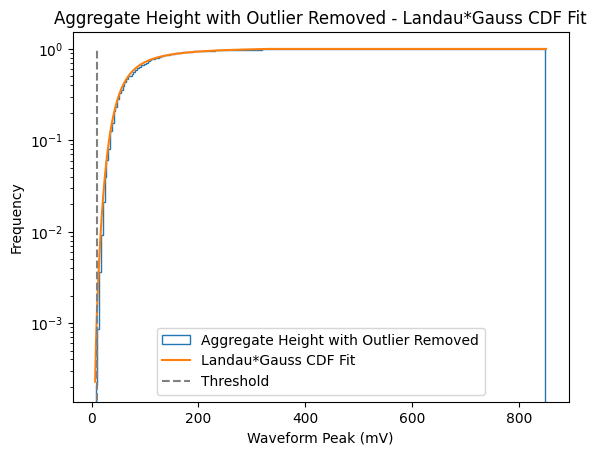

In [23]:
plt.title("Aggregate Height with Outlier Removed - Landau*Gauss CDF Fit")
plt.xlabel("Waveform Peak (mV)")
plt.ylabel("Frequency")
plt.hist(back2data,bins=249,label="Aggregate Height with Outlier Removed",histtype="step",density=True,cumulative=True)
plt.plot(x,y_cdf,label="Landau*Gauss CDF Fit")
plt.plot([thresh,thresh],[0,1],label="Threshold",linestyle="--",color="gray")
plt.yscale('log')
plt.legend()
plt.show()

Things I'm interested in looking at still:
 - What does a convolution of fitted Gauss and fitted Landau look like?
 - How does fitting the L*G change what my parameters mean?
 - Can scipy.signal.convolve speed up L*G fitting times?
 - Performing $R^2$ and $\chi^2$ tests

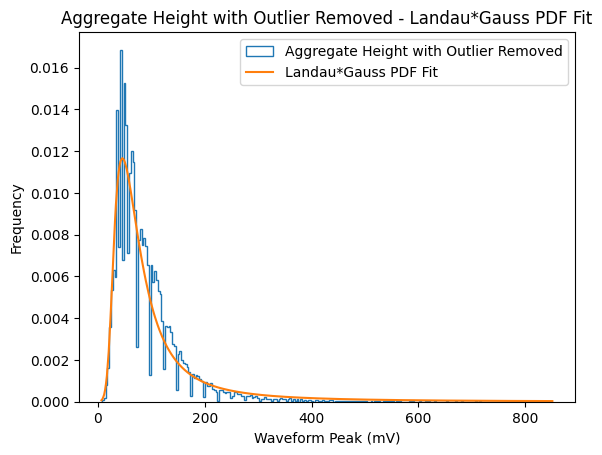

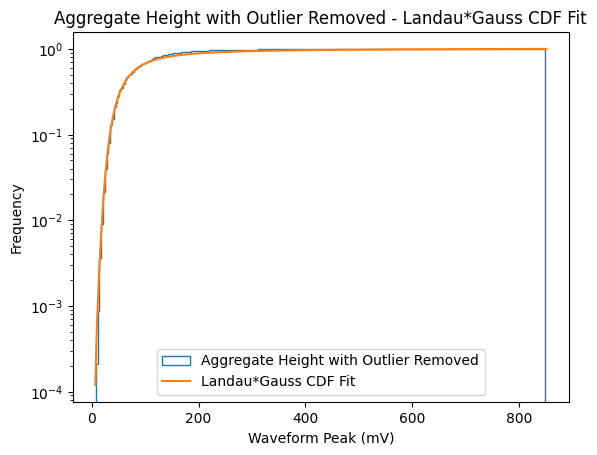

Fitted parameters: [ 33.0308405   25.47588103 448.68020365   7.75108156]


In [54]:
from scipy.interpolate import interp1d # For speed

def landau_star_gauss_fastest(mu, c, x0, sigma, l, u, grid_size=300):

    # print(l,u,grid_size)
    assert isinstance(grid_size,int)
    x_grid = np.linspace(l, u, int(grid_size))
    # print(x_grid[:5])

    dx = x_grid[1] - x_grid[0]
    # print(dx)

    landau_vals = landau.pdf(x_grid, loc=mu, scale=c)
    gauss_vals  = norm.pdf(x_grid, loc=x0, scale=sigma)

    conv = np.convolve(landau_vals, gauss_vals, mode='same') * dx
    # print(conv[:5])

    conv /= np.trapezoid(conv, x_grid)
    # print(conv[:5])

    return interp1d(x_grid, conv)

n, bins = np.histogram(aggregate_height, bins=500, density=True)
n, bins = n[:-1], bins[:-1]
half_bins = np.array([(bins[i] + bins[i+1]) / 2 for i in range(len(bins) - 1)])
l, u = min(bins), max(bins)

# Initial guesses: based on prior Landau fit and data estimates
p0 = [58.3, 24.3, np.mean(half_bins), np.std(half_bins)]  # mu, c, A, x0, sigma

# Fit with bounds to prevent negative sigma
bounds = ([0, 1e-6, np.min(half_bins), 1e-6], [np.inf, 1e4, np.max(half_bins), 1e4])
popt, pcov = curve_fit(lambda x, mu, c,x0, sigma: landau_star_gauss_fastest(mu, c, x0, sigma, l, u, 300)(x),
                       half_bins, n, p0=p0, bounds=bounds)

# Compute fitted values
landau_star_gauss_pdf = landau_star_gauss_fastest(*popt, l, u)(half_bins)

x,y_pdf,y_cdf = half_bins, landau_star_gauss_pdf, np.cumsum(landau_star_gauss_pdf)*(half_bins[1] - half_bins[0])

# Plot
plt.title("Aggregate Height with Outlier Removed - Landau*Gauss PDF Fit")
plt.xlabel("Waveform Peak (mV)")
plt.ylabel("Frequency")
plt.hist(back2data, bins=249, label="Aggregate Height with Outlier Removed", histtype="step", density=True)
plt.plot(x, y_pdf, label="Landau*Gauss PDF Fit")
plt.legend()
plt.show()

plt.title("Aggregate Height with Outlier Removed - Landau*Gauss CDF Fit")
plt.xlabel("Waveform Peak (mV)")
plt.ylabel("Frequency")
plt.hist(back2data,bins=249,label="Aggregate Height with Outlier Removed",histtype="step",density=True,cumulative=True)
plt.plot(x,y_cdf,label="Landau*Gauss CDF Fit")
plt.yscale('log')
plt.legend()
plt.show()

print("Fitted parameters:", popt)

[0.068742   0.06876676 0.09744164 0.09809718 0.10816591 0.14421155
 0.16274067 0.18252893 0.37735822 0.40644863]
1000 1000


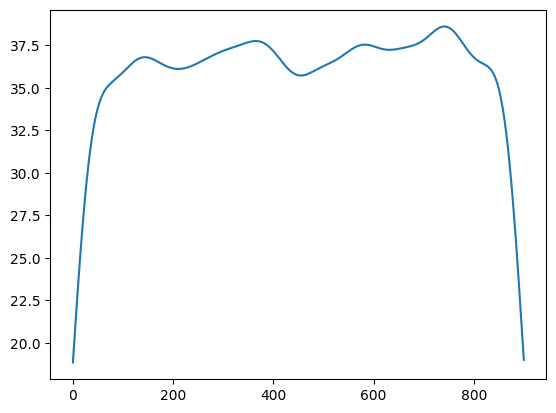

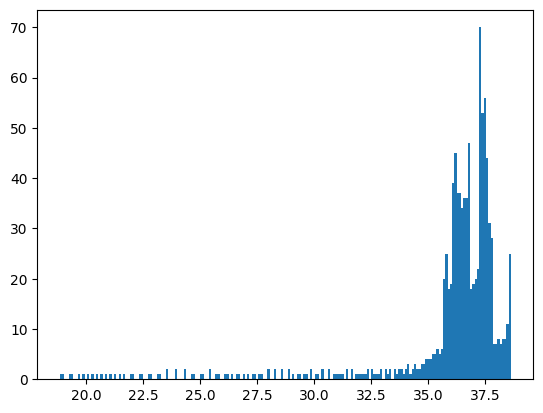

18.998226518120887


In [7]:
from scipy.stats import gaussian_kde

def event_rate_fixed(times, sigma_ps=None, resolution=1000):
    """
    times: array of timestamps in s
    sigma_ps: absolute smoothing factor in s (e.g., 5.0 for 5ps window)
    """
    times = np.sort(np.asarray(times))
    n_events = len(times)
    
    if n_events < 2:
        return np.array([]), np.array([])

    duration = times[-1] - times[0]
    rate_axis = np.linspace(times[0], times[-1], resolution)
    
    # Calculate KDE
    kde = gaussian_kde(times)
    
    # If the user provides a specific sigma in ps, we must convert it
    # to the 'relative' bandwidth scipy expects: bw = sigma / data_std
    if sigma_ps:
        data_std = np.std(times)
        kde.set_bandwidth(bw_method=sigma_ps / data_std)
    
    # Evaluate and scale from 'density' to 'events per ps'
    # kde.evaluate(x) * total_n = Rate
    rate = kde.evaluate(rate_axis) * n_events
    
    return rate_axis, rate

aggregate_time = data[4]
print(aggregate_time[:10])
rate_axis, rate = event_rate_fixed(aggregate_time)
# rate_axis, rate = rate_axis[1:-1], rate[1:-1]
print(len(rate_axis), len(rate))

plt.plot(rate_axis, rate)
plt.show()

plt.hist(rate,bins=200)
plt.show()

print(rate[-1])

Fitting Gaussian...
35.88351037969932 3.2535279084071673
36.91 ± 0.03, 0.96 ± 0.02


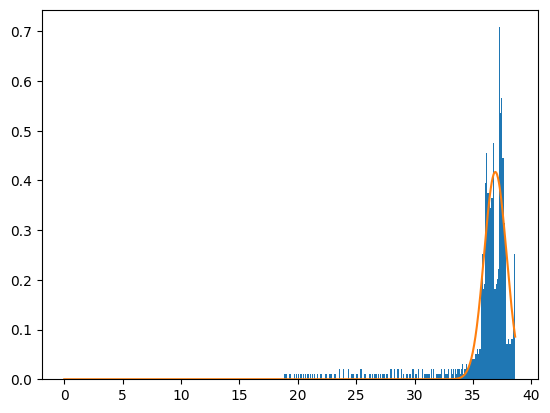

In [9]:
from analysislib import gauss_fit
from scipy.stats import norm

mean,sigma_mean,std,sigma_std = gauss_fit(rate)
print(f"{mean:.2f} ± {sigma_mean:.2f}, {std:.2f} ± {sigma_std:.2f}")

xs = np.linspace(0,np.max(rate),1000)
plt.hist(rate,bins=200,density=True)
plt.plot(xs,norm.pdf(xs,mean,std))
plt.show()

### The Overflow Issue
There seems to be an issue with overflow for height not being extracted. I want to investigate more thoroughly the overflow issue.

In [2]:
from andylib import load_file
import os
import numpy as np
import matplotlib.pyplot as plt

def extract_from_parent(n_channels,parent_dir):

   raw_dir = os.path.join(parent_dir, "RAW")

   # if not os.path.isdir(raw_dir):
   #    raise FileNotFoundError(f"RAW subdirectory not found: {raw_dir}")

   channel_data = [[],[],[],[],[]]
   channel_indices = [0]
   for i in range(n_channels):
      # if not os.path.isdir(parent_dir):
      #    raise ValueError(f"Parent directory does not exist: {parent_dir}")

      raw_dir = os.path.join(parent_dir, "RAW")

      channel_token = f"CH{i}"
      candidates = [fname for fname in os.listdir(raw_dir)
                    if os.path.isfile(os.path.join(raw_dir, fname)) and channel_token in fname]
      channel_filename = candidates[0]
      file_path = os.path.join(raw_dir, channel_filename)
      ret = load_file(file_path, lowmem=True)
      channel_indices.append(len(ret[0])+channel_indices[i])
      for i in range(len(channel_data)):
         for j in range(len(ret[i])):
            channel_data[i].append(ret[i][j])
   return np.array(channel_data),channel_indices[1:-1]

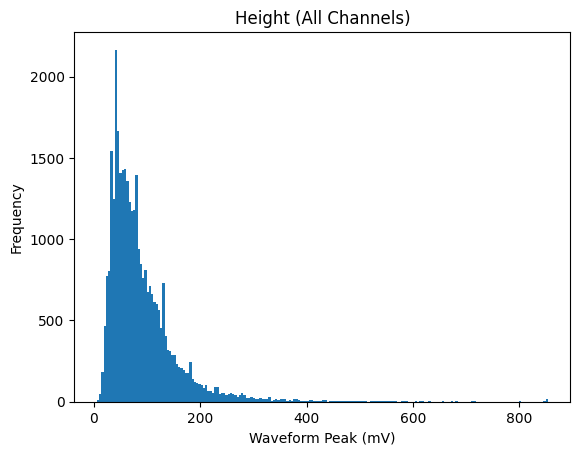

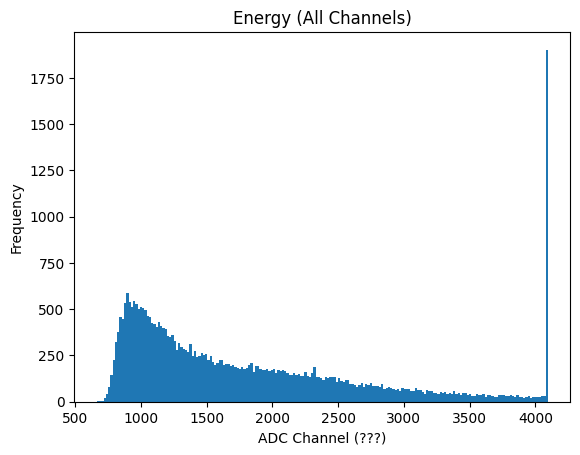

In [7]:
n_channels, parent_dir = 3,"Scenario_5_Revised_Run"
data,indices = extract_from_parent(n_channels,parent_dir)
aggregate_height, aggregate_baseline, aggregate_energy, aggregate_channel, aggregate_time = data

plt.title("Height (All Channels)")
plt.xlabel("Waveform Peak (mV)")
plt.ylabel("Frequency")
plt.hist(aggregate_height,bins=200)
plt.show()

plt.title("Energy (All Channels)")
plt.xlabel("ADC Channel (???)")
plt.ylabel("Frequency")
plt.hist(aggregate_energy,bins=200)
plt.show()

33280 33280


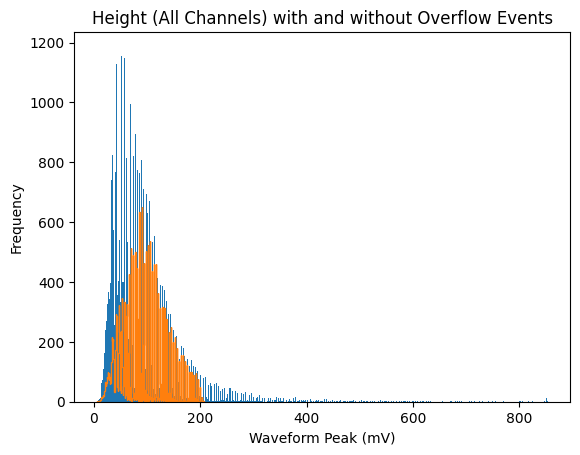

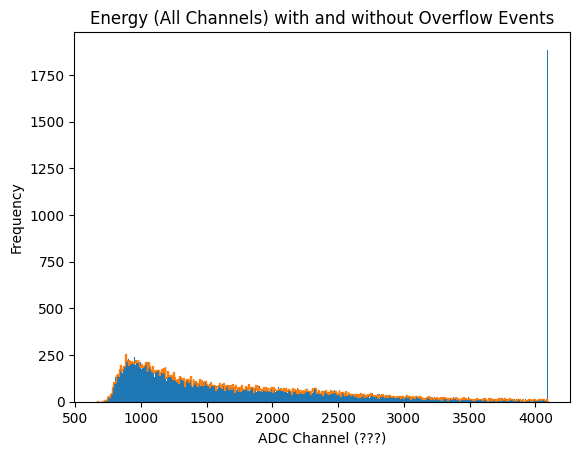

In [ ]:
# These have the same length
print(len(aggregate_energy),len(aggregate_height))

# How about removing all events entirely which have overflow energy?
mask = aggregate_energy!=4095
new_aggregate_energy = aggregate_energy[mask]
new_aggregate_height = aggregate_height[mask]

plt.title("Height (All Channels) with and without Overflow Events")
plt.xlabel("Waveform Peak (mV)")
plt.ylabel("Frequency")
plt.hist(aggregate_height,bins=500,label="All Events")
plt.hist(new_aggregate_height,bins=500,label="Without Overflow Events",histtype="step")
plt.show()

plt.title("Energy (All Channels) with and without Overflow Events")
plt.xlabel("ADC Channel (???)")
plt.ylabel("Frequency")
plt.hist(aggregate_energy,bins=500,label="All Events")
plt.hist(new_aggregate_energy,bins=500,label="Without Overflow Events",histtype="step")
plt.show()

plt.title("Event Rate (All Channels) with and without Overflow Events")
plt.xlabel("Waveform Peak (mV)")
plt.ylabel("Frequency")
plt.hist(aggregate_height,bins=500,label="All Events")
plt.hist(new_aggregate_height,bins=500,label="Without Overflow Events",histtype="step")
plt.show()

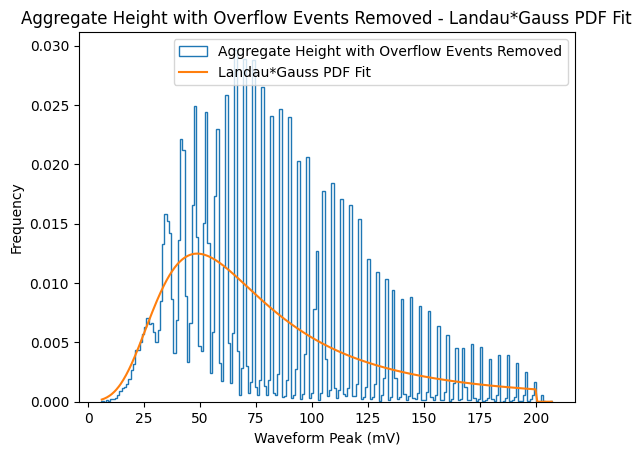

{'mu': np.float64(67.32760690375098), 'c': np.float64(26.213421678369933), 'x0': np.float64(98.65306344993381), 'sigma': np.float64(0.12775523778584116)}


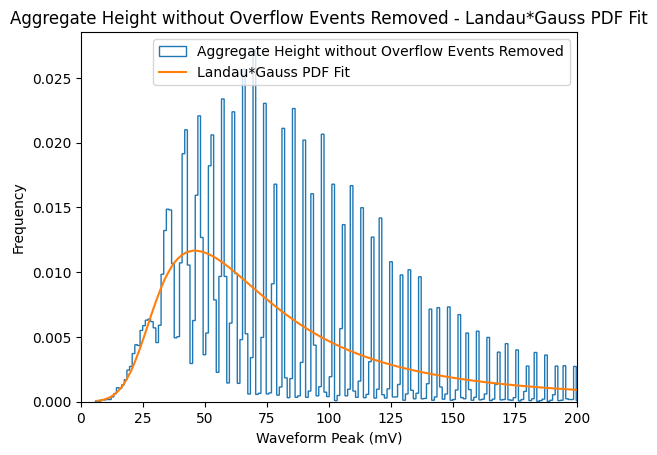

{'mu': np.float64(33.02697139008289), 'c': np.float64(25.47268653088075), 'x0': np.float64(449.5373846715673), 'sigma': np.float64(7.743825739290036)}


In [27]:
from analysislib import landau_star_gauss_fit_fastest, landau_star_gauss_fastest

n_bins = 200

# With Removing Overflow Events

n, bins = np.histogram(new_aggregate_height, bins=500, density=True)
half_bins = np.array([(bins[i] + bins[i+1]) / 2 for i in range(len(bins) - 1)])
l, u = min(bins), max(bins)

## Perform fit
mu,sigma_mu,c,sigma_c,x0,sigma_x0,sigma,sigma_sigma = landau_star_gauss_fit_fastest(new_aggregate_height)
popt = [mu,c,x0,sigma]

## Compute fit
landau_star_gauss_pdf = landau_star_gauss_fastest(*popt, l, u)(half_bins)

x,y_pdf,y_cdf = half_bins, landau_star_gauss_pdf, np.cumsum(landau_star_gauss_pdf)*(half_bins[1] - half_bins[0])

## Plot
plt.title("Aggregate Height with Overflow Events Removed - Landau*Gauss PDF Fit")
plt.xlabel("Waveform Peak (mV)")
plt.ylabel("Frequency")
plt.hist(new_aggregate_height, bins=n_bins, label="Aggregate Height with Overflow Events Removed", histtype="step", density=True)
plt.plot(x, y_pdf, label="Landau*Gauss PDF Fit")
plt.legend()
plt.show()
print(dict(zip(['mu', 'c', 'x0', 'sigma'], popt)))


# Without Removing Overflow Events

n, bins = np.histogram(aggregate_height, bins=500, density=True)
half_bins = np.array([(bins[i] + bins[i+1]) / 2 for i in range(len(bins) - 1)])
l, u = min(bins), max(bins)

## Perform fit
mu,sigma_mu,c,sigma_c,x0,sigma_x0,sigma,sigma_sigma = landau_star_gauss_fit_fastest(aggregate_height)
popt = [mu,c,x0,sigma]

## Compute fit
landau_star_gauss_pdf = landau_star_gauss_fastest(*popt, l, u)(half_bins)

x,y_pdf,y_cdf = half_bins, landau_star_gauss_pdf, np.cumsum(landau_star_gauss_pdf)*(half_bins[1] - half_bins[0])

## Plot
plt.title("Aggregate Height without Overflow Events Removed - Landau*Gauss PDF Fit")
plt.xlabel("Waveform Peak (mV)")
plt.ylabel("Frequency")
plt.hist(aggregate_height, bins=4*n_bins, label="Aggregate Height without Overflow Events Removed", histtype="step", density=True)
plt.plot(x, y_pdf, label="Landau*Gauss PDF Fit")
plt.xlim(0,200)
plt.legend()
plt.show()
print(dict(zip(['mu', 'c', 'x0', 'sigma'], popt)))